# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. we add the penalty to minimize the MSE (or maximise accuracy).My adding a penalty, complex models become more expensive
2. shrinking then shrinking the coefficients towards 0 forces the model to have a lower variance, because smaller coefficients means the same changes in lead to smaller changes in your prediction
3. Lasso uses the absolute value of the coefficients, whereas Ridge uses the squared value of the coefficients.LASSO "zeros out" variables and selects a specific model, while Ridge smoothly shrinks all the coefficients towards 0.
4. We usually use StandardScaler to scale variables in regularized regression .We usually z-score normalize numerical variables because regulization penalizes coefficient size.
5. To decide which penalty value, we cross validate to find the value that minimizes validation error
6. No, we do not include the penalty term in evaluating the cross validated MSE. It is used during the training phase but for the actual testing bit is to test it on new data

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 268 (delta 2), reused 1 (delta 1), pack-reused 264 (from 3)
Receiving objects: 100% (268/268), 17.11 MiB | 35.69 MiB/s, done.
Resolving deltas: 100% (123/123), done.
Download complete
Extracting data files...
Data extracted


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree=2, include_bias=False)
df = pd.read_csv('./data/cars_hw.csv')
df.head()

df["Age"] = 2026 - df["Make_Year"]
feature = df[["Mileage_Run","Age"]]
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(feature)
poly_names = poly.get_feature_names_out(["Mileage_Run","Age"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
y = df["Price"]

linear_model = LinearRegression()
linear_model.fit(X_scaled, y)
coeffs_lin = pd.Series(linear_model.coef_, index=poly_names)

interaction = "Mileage_Run Age"

print(f"observations of the interactions {interaction}: {'Postive' if coeffs_lin[interaction]>0 else 'Negative'}")




observations of the interactions Mileage_Run Age: Negative


mileage worsenes as age increases

In [ ]:
alphas = np.logspace(1,3,20)
model = LassoCV(cv=20, alphas=alphas, random_state=100, max_iter=100000)
model = model.fit(X_scaled, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

Optimal cost hyperparameter: 1000.0


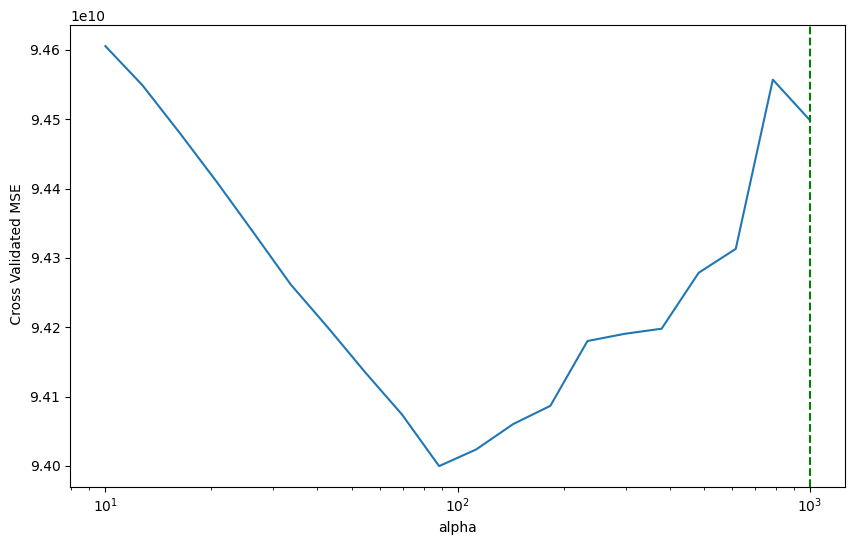

Optimal cost hyperparameter: 1000.0


In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel(" Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

plt.show()
print(f"Optimal cost hyperparameter: {alpha_star}")

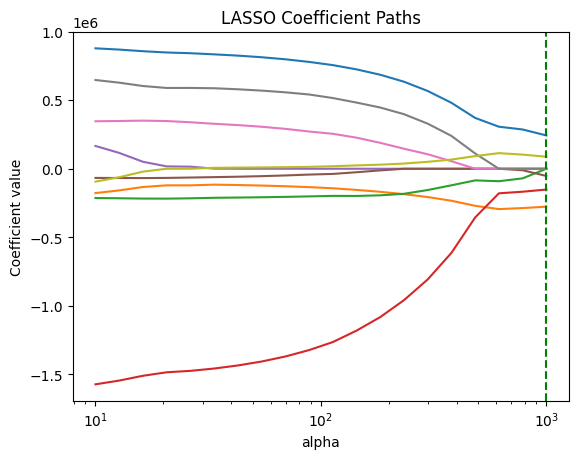

In [ ]:
coefs = []
for alpha in alphas: # For each alpha value,
    model = Lasso(alpha=alpha, max_iter=100000) # Create a lasso model
    model = model.fit(X_scaled,y) # Run the regression
    coefs.append(model.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=poly_names[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [ ]:
coefficients = model.coef_
selected_features = poly_names[model.coef_ != 0]
print(f"Selected Features: {selected_features}")

Selected Features: ['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']


In [ ]:
zero_count = np.sum(coefficients == 0)
proportion_zero = zero_count / len(coefficients)

print("--- Selected Features ---")
print(selected_features)
print(f"\nProportion of features set to zero: {proportion_zero:.2%}")

--- Selected Features ---
['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']

Proportion of features set to zero: 44.44%


In [ ]:
coeffs_lasso = pd.Series(model.coef_, index=poly_names)
coeffs_lin = pd.Series(linear_model.coef_, index=poly_names)
comparison = pd.DataFrame({"Linear": coeffs_lin, "Lasso": coeffs_lasso})

comparison["increase"] = comparison["Lasso"].abs() > comparison["Linear"].abs()
comparison["sign_change"] = comparison["Lasso"] * comparison["Linear"] < 0
print(comparison)



                         Linear          Lasso  increase  sign_change
Mileage_Run        9.117748e+05  242953.216388     False        False
Age               -2.481722e+05 -276500.895776      True        False
Mileage_Run^2     -2.072926e+05      -0.000000     False        False
Mileage_Run Age   -1.671212e+06 -151598.545767     False        False
Age^2              3.505507e+05      -0.000000     False        False
Mileage_Run^3     -6.514490e+04  -52410.347536     False        False
Mileage_Run^2 Age  3.388195e+05      -0.000000     False        False
Mileage_Run Age^2  7.167816e+05      -0.000000     False        False
Age^3             -2.100379e+05   87796.740706     False         True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
y = df["DEATH_EVENT"]
df.head()

features_names = ['age', 'ejection_fraction', 'serum_creatinine']
features = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(features)
poly_names = poly.get_feature_names_out(features_names)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

cat_variables = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
cat_poly = PolynomialFeatures(include_bias=False, interaction_only=True)

X_cat_interact = cat_poly.fit_transform(cat_variables)
cat_names = cat_poly.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

# --- Part C: Combine ---
X_final = np.hstack([X_scaled, X_cat_interact])
all_feature_names = np.concatenate([poly_names, cat_names])



In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_final, y)
coeffs_lin = pd.Series(linear_model.coef_, index=all_feature_names)

print(coeffs_lin)

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

The linea mode shows counterintuitive signs, like age^2 being negative wheras age is positive.

In [ ]:
alphas = np.logspace(-5,5,30)
m = LassoCV(cv=20, alphas=alphas, random_state=100, max_iter=100000)
m = m.fit(X_final, y)

alpha_star = m.alpha_
print(f'Optimal cost hyperparameter: {alpha_star}')

Optimal cost hyperparameter: 0.005736152510448681


Optimal cost hyperparameter: 0.005736152510448681


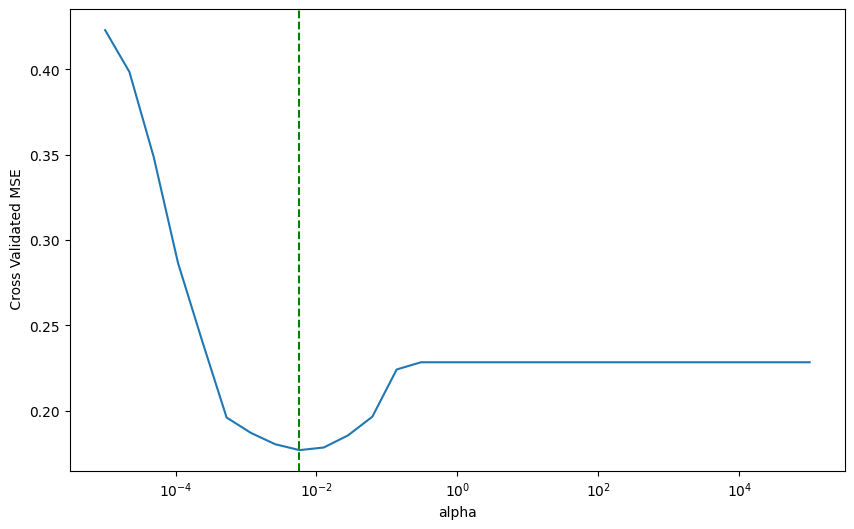

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel(" Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

plt.show()

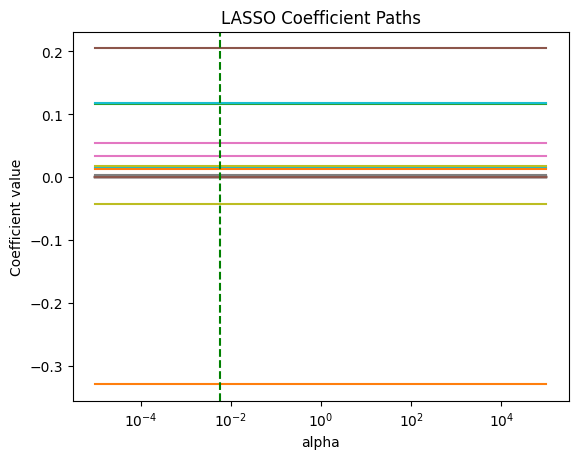

In [ ]:
coefs = []
for a in alphas: # For each alpha value,
    m = Lasso(alpha=a, max_iter=100000) # Create a lasso model
    m = m.fit(X_final,y) # Run the regression
    coefs.append(m.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [ ]:
lasso_coeffs = pd.Series(m.coef_, index=all_feature_names)
coeffs_lin = pd.Series(linear_model.coef_, index=all_feature_names)

coefficients = m.coef_
selected_features = lasso_coeffs[lasso_coeffs != 0]
print(f"Selected Features: {selected_features}")

zero_count = np.sum(lasso_coeffs == 0)
proportion_zero = zero_count / len(all_feature_names)

print(f"\nProportion of features set to zero: {proportion_zero:.2%}")

Selected Features: ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Proportion of features set to zero: 58.62%


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_final, y)

comparison2 = pd.DataFrame({"features": all_feature_names, "linear": linear_model.coef_,'lasso': m.coef_})

comparison2["increase"] = comparison2["lasso"].abs() > comparison2["linear"].abs()
comparison2["sign_change"] = np.sign(comparison2["linear"]) != np.sign(comparison2["lasso"])
print(comparison2)

selected_only = comparison2[comparison2['lasso'] != 0]
print("--- Comparison Table (Selected Features) ---")
print(selected_only[['features', 'linear', 'lasso', 'increase', 'sign_change']])





                                  features    linear     lasso  increase  \
0                                      age  1.539156 -0.000000     False   
1                        ejection_fraction -2.192494 -0.329656     False   
2                         serum_creatinine -0.853588  0.116875     False   
3                                    age^2 -3.678654  0.000000     False   
4                    age ejection_fraction -0.600918 -0.000000     False   
5                     age serum_creatinine  1.841563  0.000000     False   
6                      ejection_fraction^2  3.430976  0.000000     False   
7       ejection_fraction serum_creatinine  2.673394  0.000000     False   
8                       serum_creatinine^2 -2.647041 -0.000000     False   
9                                    age^3  1.993135  0.117992     False   
10                 age^2 ejection_fraction  0.908026  0.000000     False   
11                  age^2 serum_creatinine -0.697522  0.000000     False   
12          

the comparison data shows that the linear model has high variavne and shows multicollinearity.Lasso resolved these issues though selection and roughly 60% of the coefficients are 0. Coefficients have usally decreased in magnitute as there is more False  in the increase column. There are several true values in the sign_change column such as serum_creatinine  was -0.85 and later in lasso became 0.11. Lasso makes more sense.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

citation: ChatGPT to help me with the latex

## Ridge Regression Objective Function

$$
J(b_0, b_1)
=
\frac{1}{n}\sum_{i=1}^{n}(\tilde y_i - b_0 - b_1 \tilde x_i)^2
+
\alpha b_1^2
$$

ridge does not change the intercept


## Final Answers

$$
b_0 = 0
$$

$$
b_1 = \frac{\frac{1}{n}\sum_{i=1}^{n}\tilde x_i \tilde y_i}{\frac{1}{n}\sum_{i=1}^{n}\tilde x_i^2 + \alpha}
$$

if the alpha is increased, the slope coefficent goes towards 0.

the function is not differentiable at \(b_1=0\).Insteas, we will use subgradients. This leads to a partial solution where the coefficients can be exaclty 0.
its optimal to set \(b_1=0\) when the penalty cost is stronger